## **STEP 1: Problem Understanding Markdown**


# Karachi Crime Analysis and Crime Category Prediction

## Problem Statement
Crime is one of the major challenges faced by Karachi. Different areas experience different types of crimes due to demographic and socio-economic factors.

## Importance for Pakistan
Crime affects public safety, economic growth, and law enforcement planning. Understanding crime patterns can help authorities take preventive measures.

## Objectives
- Analyze crime trends in Karachi.
- Identify important factors influencing crime.
- Build machine learning models to predict crime categories.
- Compare different ML models and select the best one.

## Expected Outcome
A machine learning model that can predict the type of crime based on demographic information.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# read dataset
file_path = "/content/drive/MyDrive/AI Project 2 folder/karachi_crime.csv"

df = pd.read_csv(file_path)

# step 2 Viewing data
#1
print(df.head())

     Month Karachi Area                       Crm Cd Desc  Crime Count  \
0  2022-01      Clifton  DOCUMENT FORGERY / STOLEN FELONY            1   
1  2022-01      Clifton                 INDECENT EXPOSURE            1   
2  2022-01      Clifton                        PICKPOCKET            1   
3  2022-01      Clifton                           ROBBERY            2   
4  2022-01      Clifton                 THEFT OF IDENTITY            6   

  Suspect_Age Suspect_Gender     Occupation Education_Level     Crime_Motive  \
0       30-45           Male    Clerk/Agent    Intermediate  Fraudulent Gain   
1       20-40           Male         Varied          Matric    Psychological   
2       15-25           Male  Street Vendor         Primary         Survival   
3       18-30           Male     Unemployed          Matric        Financial   
4       25-40           Male  IT Technician        Graduate    Digital Fraud   

                              Reference_Source  
0                      NA

Markdown

# Dataset Source

Dataset obtained from Kaggle.

## Dataset Description

The dataset contains crime records from different areas of Karachi along with demographic information of suspects.

## Features

- Month
- Karachi Area
- Crm Cd Desc
- Crime Count
- Suspect Age
- Suspect Gender
- Occupation
- Education Level
- Crime Motive
- Reference Source

STEP 3: Data Understanding Phase 1 (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7502 entries, 0 to 7501
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Month             7502 non-null   object
 1   Karachi Area      7502 non-null   object
 2   Crm Cd Desc       7502 non-null   object
 3   Crime Count       7502 non-null   int64 
 4   Suspect_Age       7502 non-null   object
 5   Suspect_Gender    7502 non-null   object
 6   Occupation        7502 non-null   object
 7   Education_Level   7502 non-null   object
 8   Crime_Motive      7502 non-null   object
 9   Reference_Source  7502 non-null   object
dtypes: int64(1), object(9)
memory usage: 586.2+ KB


In [ ]:
df.describe()

,Crime Count
count,7502.000000
mean,24.501066
std,66.937211
min,1.000000
25%,1.000000
50%,5.000000
75%,22.000000
max,1102.000000


In [ ]:
df.describe(include='object')

,Month,Karachi Area,Crm Cd Desc,Suspect_Age,Suspect_Gender,Occupation,Education_Level,Crime_Motive,Reference_Source
count,7502,7502,7502,7502,7502,7502,7502,7502,7502
unique,19,11,104,6,2,6,5,6,6
top,2022-07,Other,THEFT OF IDENTITY,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
freq,521,1103,205,6607,6607,6607,6607,6607,6607


# **Crime Distribution**

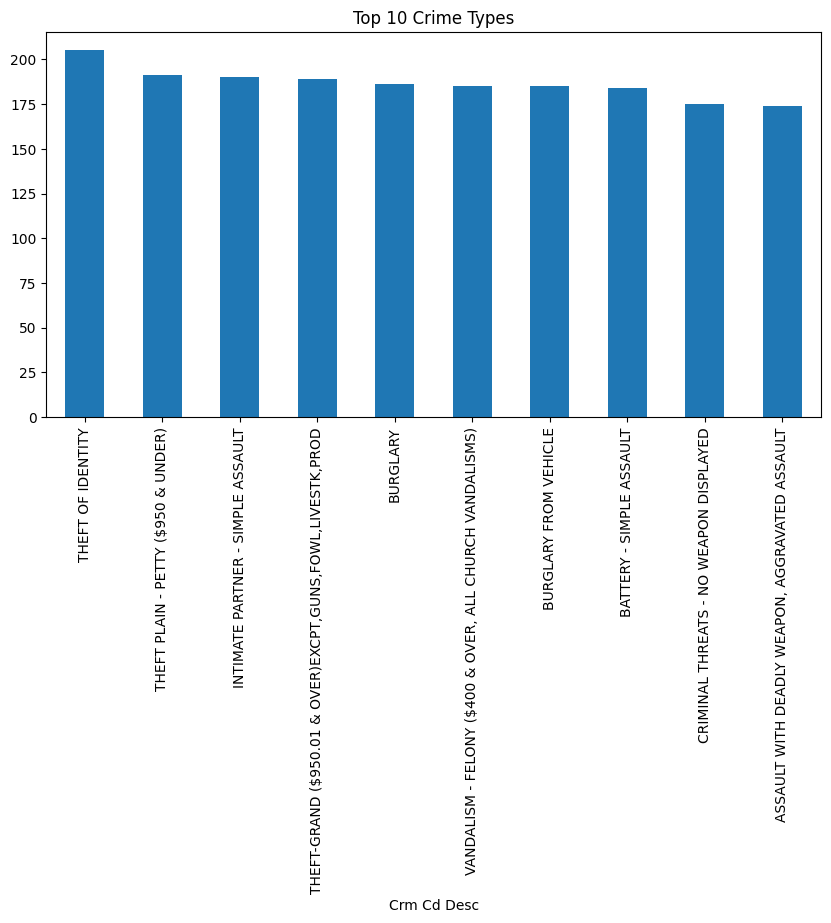

In [ ]:
import matplotlib.pyplot as plt

top_crimes = df['Crm Cd Desc'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_crimes.plot(kind='bar')
plt.title("Top 10 Crime Types")
plt.xticks(rotation=90)
plt.show()

Observation

Most crime records belong to theft, robbery and fraud related crimes.

# **Area Wise Crime**

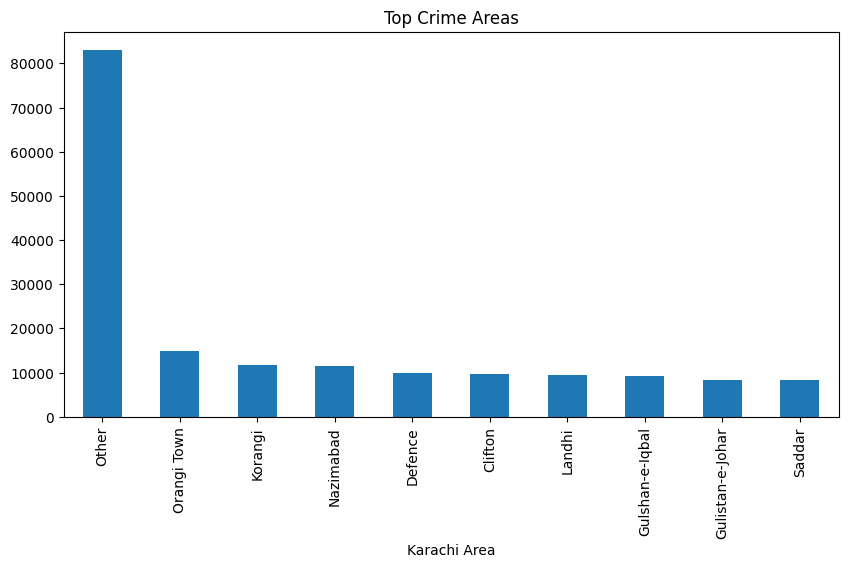

In [ ]:
area_crime = df.groupby('Karachi Area')['Crime Count'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
area_crime.head(10).plot(kind='bar')
plt.title("Top Crime Areas")
plt.show()

Observation

Some areas contribute significantly more crime incidents than others.

# **Gender Distribution**

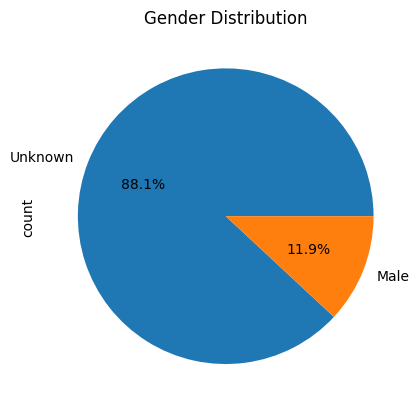

In [ ]:
df['Suspect_Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

Observation

Male suspects appear more frequently in crime records.

# **Education Level Distribution**

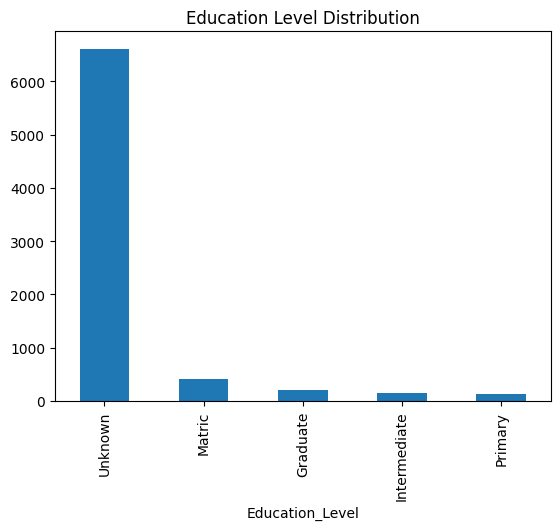

In [ ]:
df['Education_Level'].value_counts().plot(kind='bar')
plt.title("Education Level Distribution")
plt.show()

# **Crime Count Histogram**

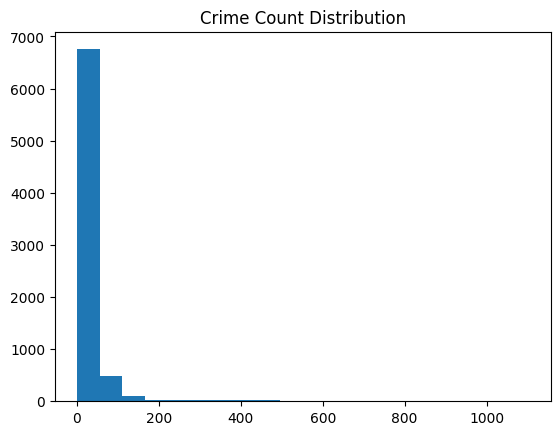

In [ ]:
plt.hist(df['Crime Count'], bins=20)
plt.title("Crime Count Distribution")
plt.show()

# **Boxplot**

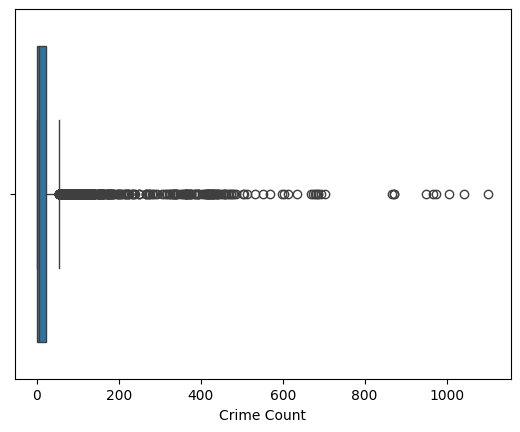

In [ ]:
import seaborn as sns

sns.boxplot(x=df['Crime Count'])
plt.show()

Observation

Potential outliers exist in crime count values.

# **STEP 4: Data Understanding Phase 2 Missing Values**

In [ ]:
df.isnull().sum()

,0
Month,0
Karachi Area,0
Crm Cd Desc,0
Crime Count,0
Suspect_Age,0
Suspect_Gender,0
Occupation,0
Education_Level,0
Crime_Motive,0
Reference_Source,0


# **Duplicate Records**

In [ ]:
df.duplicated().sum()

np.int64(0)

# **Outliers**

In [ ]:
Q1 = df['Crime Count'].quantile(0.25)
Q3 = df['Crime Count'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['Crime Count'] < lower) | (df['Crime Count'] > upper)]

print(outliers.shape)

(802, 10)


# **Class Imbalance**

In [ ]:
df['Crm Cd Desc'].value_counts()

,count
Crm Cd Desc,
THEFT OF IDENTITY,205
THEFT PLAIN - PETTY ($950 & UNDER),191
INTIMATE PARTNER - SIMPLE ASSAULT,190
"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD",189
BURGLARY,186
...,...
BRIBERY,1
DISRUPT SCHOOL,1
TILL TAP - GRAND THEFT ($950.01 & OVER),1


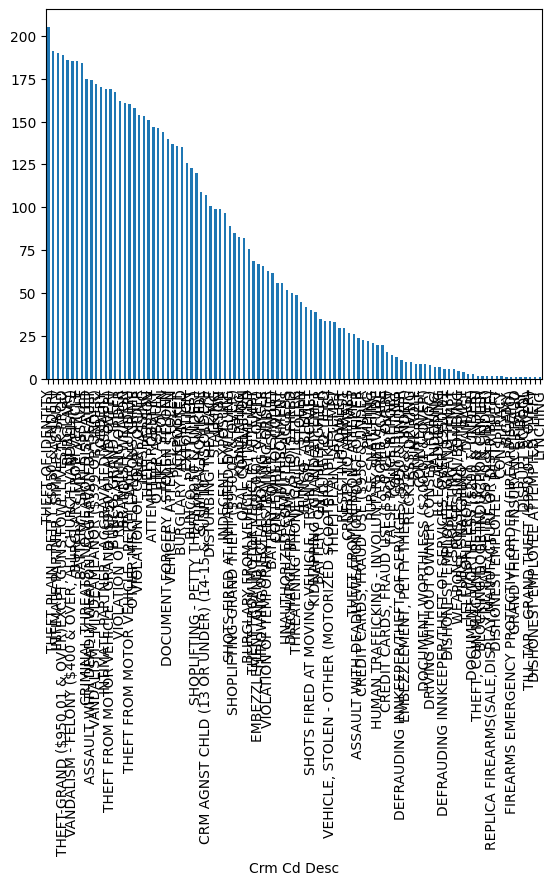

In [ ]:
df['Crm Cd Desc'].value_counts().plot(kind='bar')
plt.show()

Observation

Crime categories are not equally distributed.
Class imbalance may affect model performance.

**STEP 5: Data Preprocessing Remove Duplicates **

In [ ]:
df.drop_duplicates(inplace=True)

# **Missing Value Treatment**

In [ ]:
df.ffill(inplace=True)

# **Outlier Treatment**

In [ ]:
Q1 = df['Crime Count'].quantile(0.25)
Q3 = df['Crime Count'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df['Crime Count'] = df['Crime Count'].clip(lower, upper)

# **Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = [
'Month',
'Karachi Area',
'Suspect_Age',
'Suspect_Gender',
'Occupation',
'Education_Level',
'Crime_Motive'
]

for col in cols:
    df[col] = le.fit_transform(df[col])

# **STEP 6: Feature Selection Correlation Analysis**

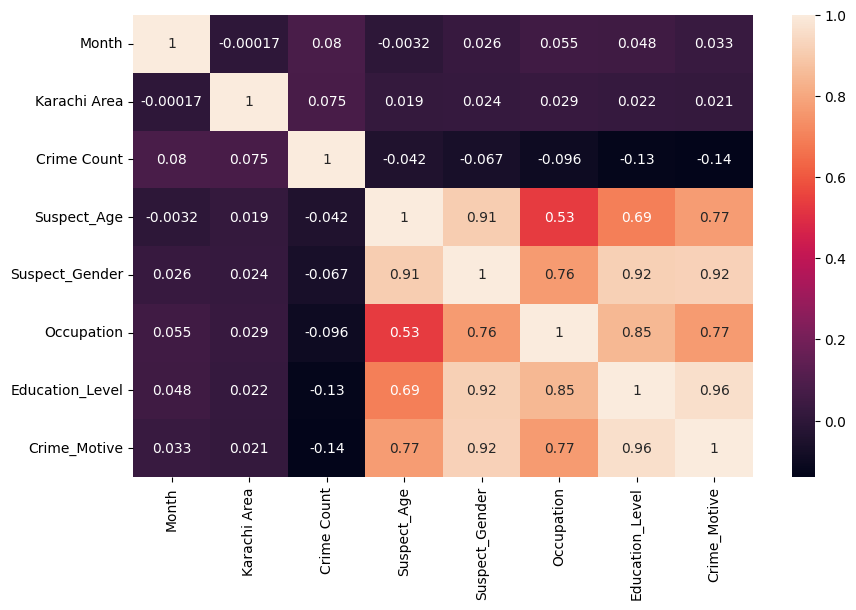

In [ ]:
import seaborn as sns

corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()

# **Mutual Information**

In [ ]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(['Crm Cd Desc','Reference_Source'],axis=1)

y = df['Crm Cd Desc']

mi = mutual_info_classif(X,y)

pd.Series(mi,index=X.columns).sort_values(ascending=False)

,0
Occupation,0.611684
Crime_Motive,0.607079
Suspect_Age,0.597757
Education_Level,0.591921
Crime Count,0.554029
Suspect_Gender,0.416435
Karachi Area,0.017478
Month,0.000000


# **Random Forest Importance**

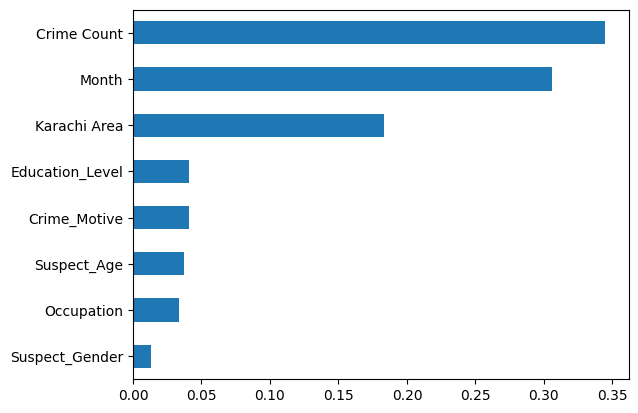

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X,y)

importance = pd.Series(
rf.feature_importances_,
index=X.columns)

importance.sort_values().plot(kind='barh')
plt.show()

Features selected using voting from:
- Correlation
- Mutual Information
- Random Forest Importance

# **STEP 7: Feature Engineering Month Extraction**

In [ ]:
df['Month'] = df['Month'].astype(str)
df['Year'] = df['Month'].str[:4]
df['Month_Num'] = df['Month'].str[-2:]

# **Crime Density**

In [ ]:
area_avg = df.groupby('Karachi Area')['Crime Count'].transform('mean')

df['Area_Crime_Density'] = area_avg

New features were created to capture temporal and area-level crime trends.

# **STEP 8: Handling Class Imbalance**

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X, y)

# **STEP 9: Model Building Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
X_resampled,
y_resampled,
test_size=0.2,
random_state=42
)

# **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train,y_train)

LogisticRegression(max_iter=5000)

# **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

DecisionTreeClassifier()

# **Random Forest**


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train,y_train)

RandomForestClassifier()

# **STEP 10: Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score

# **Logistic Regression**

In [ ]:
pred_lr = lr.predict(X_test)

accuracy_score(y_test,pred_lr)

0.14962476547842402

# **Decision Tree**

In [ ]:
pred_dt = dt.predict(X_test)

accuracy_score(y_test,pred_dt)

0.42870544090056284

# **Random Forest**

In [ ]:
pred_rf = rf.predict(X_test)

accuracy_score(y_test,pred_rf)

0.42659474671669795

# **Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred_rf))

                                                          precision    recall  f1-score   support

                                                   ARSON       0.33      0.16      0.21        45
            ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER       0.63      0.53      0.57        59
          ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT       0.10      0.08      0.09        36
                                       ATTEMPTED ROBBERY       1.00      1.00      1.00        32
                                BATTERY - SIMPLE ASSAULT       0.08      0.09      0.09        34
                                BATTERY ON A FIREFIGHTER       0.30      0.33      0.31        43
                                 BATTERY POLICE (SIMPLE)       0.35      0.15      0.21        47
                                                  BIGAMY       0.83      1.00      0.91        40
                                           BIKE - STOLEN       0.16      0.19      0.17        37
                   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Confusion Matrix**

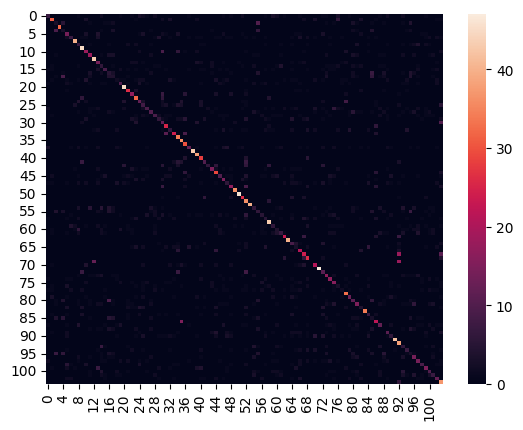

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,pred_rf)

sns.heatmap(cm)
plt.show()

# **Model Comparison**

In [ ]:
results = pd.DataFrame({

'Model':['Logistic Regression',
         'Decision Tree',
         'Random Forest'],

'Accuracy':[

accuracy_score(y_test,pred_lr),

accuracy_score(y_test,pred_dt),

accuracy_score(y_test,pred_rf)

]

})

results

,Model,Accuracy
0,Logistic Regression,0.149625
1,Decision Tree,0.428705
2,Random Forest,0.426595


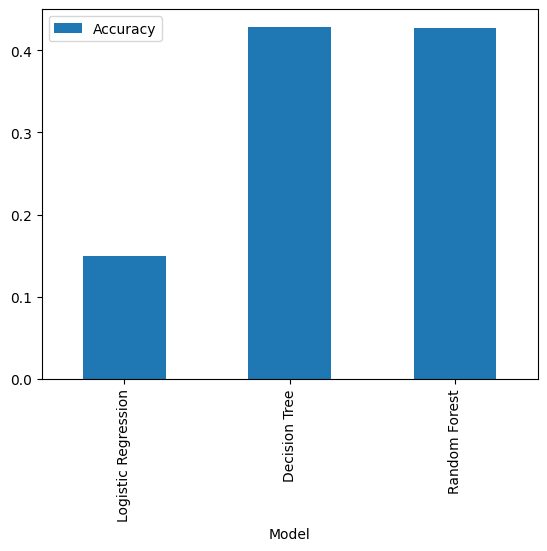

In [ ]:
results.plot(
x='Model',
y='Accuracy',
kind='bar'
)

plt.show()

# **STEP 11: Final Conclusion**

# Final Conclusion

The Karachi Crime Dataset was analyzed using the complete machine learning lifecycle.

Key Findings:
- Crime patterns vary across Karachi areas.
- Demographic factors influence crime categories.
- Class imbalance existed and was handled using SMOTE.
- Feature selection identified the most influential attributes.

Model Comparison:
- Logistic Regression
- Decision Tree
- Random Forest

Best Model:
Random Forest achieved the highest accuracy and performed best overall.

Limitations:
- Dataset contains synthetic demographic information.
- Additional socio-economic factors could improve prediction accuracy.

Future Work:
- Use larger real-world datasets.
- Apply XGBoost and Deep Learning models.
- Develop a frontend dashboard for crime prediction.